In [1]:
import numpy as np
import netCDF4 as nc
from matplotlib import cm
import matplotlib.pyplot as plt
import scipy.signal as sg
import torch.utils.data as dat
import datetime
import glob

In [2]:
input_dir = "/scratch/projects/gerberlab/WRF/INPUT/"
output_dir = "/scratch/projects/gerberlab/WRF/OUTPUT/"
case_i = "input_1deg_case1/"
case_o = "mf_case1/uw/sgs_tau/"
dayfile = "2016-08-05.nc"

In [3]:
class GenericNC4Dataset(dat.Dataset):
    def __init__(self):
        self.dset = np.zeros((1,1))
        self.mean = np.zeros(1)
        self.stdev = 0.0
        self.num_vecs_total = 0
        self.szs = []

    def set_vars(self, _dset, _mean, _stdev):
        self.dset = _dset
        self.mean = _mean
        self.stdev = _stdev
        self.num_vecs_total = _dset.shape[0]

    def set_vars_from_file(self, dset_by_file, var_name, ugly_shape=False):
        # Preprocess into a 2D array dset[i,j] = jth component of vector i
        num_vecs_total = 0
        if ugly_shape:
            sz = dset_by_file[0][0][var_name].variables["tau_g"][:].data.shape
            if len(sz) == 3:
                sz = [sz[0], 1, sz[1], sz[2]]
            nz = sz[1]
            for case in range(len(dset_by_file)):
                for idx_f in range(len(dset_by_file[case])):
                    sz = dset_by_file[case][idx_f][var_name].variables["tau_g"][:].data.shape
                    if len(sz) == 3:
                        sz = [sz[0], 1, sz[1], sz[2]]
                    self.szs.append(sz)
                    file_vector_count = sz[0]*sz[2]*sz[3]
                    assert nz == sz[1]
                    num_vecs_total += file_vector_count
            
        else:
            sz = dset_by_file[0][0].variables[var_name][:].data.shape
            if len(sz) == 3:
                sz = [sz[0], 1, sz[1], sz[2]]
            nz = sz[1]
            for case in range(len(dset_by_file)):
                for idx_f in range(len(dset_by_file[case])):
                    sz = dset_by_file[case][idx_f].variables[var_name][:].data.shape
                    if len(sz) == 3:
                        sz = [sz[0], 1, sz[1], sz[2]]
                    self.szs.append(sz)
                    file_vector_count = sz[0]*sz[2]*sz[3]
                    assert nz == sz[1]
                    num_vecs_total += file_vector_count

        self.num_vecs_total = num_vecs_total
        self.dset = np.zeros((num_vecs_total, nz))
        self.mean = np.zeros(nz)
        self.stdev = 0.0

        if ugly_shape:
            idx = 0
            for case in range(len(dset_by_file)):
                print(var_name+"\t"+str(case))
                for idx_f in range(len(dset_by_file[case])):
                    sz = dset_by_file[case][idx_f][var_name].variables["tau_g"][:].data.shape
                    if len(sz) == 3:
                        sz = [sz[0], 1, sz[1], sz[2]]
                    file_vector_count = sz[0]*sz[2]*sz[3]
                    # move z axis to last position so reshaping is easier
                    tmp = np.swapaxes(dset_by_file[case][idx_f][var_name].variables["tau_g"][:].data, 1, 3)
                    self.dset[idx:idx+file_vector_count, :] = tmp.reshape(file_vector_count, sz[1])
                    idx += file_vector_count
        else:
            idx = 0
            for case in range(len(dset_by_file)):
                print(var_name+"\t"+str(case))
                for idx_f in range(len(dset_by_file[case])):
                    sz = dset_by_file[case][idx_f].variables[var_name][:].data.shape
                    if len(sz) == 3:
                        sz = [sz[0], 1, sz[1], sz[2]]
                    file_vector_count = sz[0]*sz[2]*sz[3]
                    # move z axis to last position so reshaping is easier
                    tmp = np.swapaxes(dset_by_file[case][idx_f].variables[var_name][:].data, 1, 3)
                    self.dset[idx:idx+file_vector_count, :] = tmp.reshape(file_vector_count, sz[1])
                    idx += file_vector_count
            
        # Remove mean and divide by stdev
        #self.mean = np.mean(self.dset,axis=0)
        #self.dset -= self.mean
        # Yes, I know the variance is sum(...)/(n-1) rather than /n. n is large here so it doesn't matter
        #self.stdev = np.sqrt(np.mean(self.dset**2))

    def __len__(self):
        return self.dset.shape[0]
    
    def __getitem__(self, idx):
        return self.dset[idx,:]
    
    def randomize(self, test_frac, seed=None):
        # shuffle dataset, separating out test data
        nvecs = len(self)
        np.random.seed(seed)
        perm = np.random.permutation(nvecs)
        n_train = int(np.ceil((1-test_frac)*nvecs))
        train_dset = GenericNC4Dataset()
        test_dset = GenericNC4Dataset()
        train_dset.set_vars(self.dset[perm[:n_train]], self.mean, np.sqrt(np.mean(self.dset[perm[:n_train]]**2)))
        test_dset.set_vars(self.dset[perm[n_train:]], self.mean, np.sqrt(np.mean(self.dset[perm[n_train:]]**2)))
        return train_dset, test_dset

    #def reconstitute(self, idx_lo, idx_hi):
    #    # Return vectors idx_lo:idx_hi with mean and stddev returned to original
    #    batch = self.dset[idx_lo:idx_hi,:] + 0.0
    #    batch *= self.stdev
    #    batch += self.mean
    #    return batch

In [4]:
input_dir = "/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case"
output_dir = "/scratch/projects/gerberlab/WRF/OUTPUT/mf_case"

# Loop over the folders. In each, find list of datafiles and begin date
begindates = []
cases = [1, 2, 3, 4, 5, 6, 7, 9, 10]
ifiles = [[] for case in cases]
ofiles = [[] for case in cases]
for case in range(len(cases)):
    idir = input_dir+str(cases[case])+"/"
    odir = output_dir+str(cases[case])+"/"
    print(idir)
    # lists of datafile names
    namelist = sorted(glob.glob("????-??-??.nc",root_dir=idir))
    print(namelist)
    # since files are stored in alphabetical order first in glob list should be 1st chronologically
    d = namelist[0]
    begindates.append(datetime.datetime(int(d[:4]),int(d[5:7]),int(d[8:10])))
    # turn file names into open ncfiles
    ifiles[case] = [nc.Dataset(idir+name,"r",format="NETCDF4") for name in namelist]
    ofiles_tmp = []
    for i in range(len(namelist)):
        ofiles_tmp.append({})
        for var in ['uu', 'uv', 'uw', 'vv', 'vw']:
            ofiles_tmp[i][var] = nc.Dataset(odir+var+'/sgs_tau/'+namelist[i],"r",format="NETCDF4")
    ofiles[case] = ofiles_tmp

train_filelist = [ifiles, ofiles]

/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case1/
['2016-08-03.nc', '2016-08-04.nc', '2016-08-05.nc', '2016-08-06.nc', '2016-08-07.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case2/
['2020-01-13.nc', '2020-01-14.nc', '2020-01-15.nc', '2020-01-16.nc', '2020-01-17.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case3/
['2020-01-13.nc', '2020-01-14.nc', '2020-01-15.nc', '2020-01-16.nc', '2020-01-17.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case4/
['2017-05-28.nc', '2017-05-29.nc', '2017-05-30.nc', '2017-05-31.nc', '2017-06-01.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case5/
['2020-01-13.nc', '2020-01-14.nc', '2020-01-15.nc', '2020-01-16.nc', '2020-01-17.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case6/
['2017-05-28.nc', '2017-05-29.nc', '2017-05-30.nc', '2017-05-31.nc', '2017-06-01.nc']
/scratch/projects/gerberlab/WRF/INPUT/input_1deg_case7/
['2017-05-28.nc', '2017-05-29.nc', '2017-05-30.nc', '2017-05-31.nc', '2017-06-01.nc']
/scrat

In [5]:
training_data = {}
vars = ["U", "V", "T", "UU", "UV", "UW", "VV", "VW"]
v2io = {"U": 0, "V": 0, "T": 0, "UU": 1, "UV": 1, "UW": 1, "VV": 1, "VW": 1}
v2k = {"U": "u1deg", "V": "v1deg", "T": "t1deg", "UU":"uu", "UV":"uv", "UW":"uw", "VV":"vv", "VW":"vw"}

for var in ["UW"]:
    if v2io[var] == 0:
        zdim = train_filelist[v2io[var]][case][0].variables[v2k[var]].shape[1]
    elif v2io[var]:
        zdim = train_filelist[v2io[var]][case][0][v2k[var]].variables["tau_g"].shape[1]
    training_data[var] = GenericNC4Dataset()
    # GW fluxes are stored in an ugly manner requiring a different loading scheme; hence ugly_shape=bool(v2io[var])
    training_data[var].set_vars_from_file(train_filelist[v2io[var]], v2k[var], bool(v2io[var]))

uw	0
uw	1
uw	2
uw	3
uw	4
uw	5
uw	6
uw	7
uw	8


In [6]:
nvec,nlev = training_data["UW"].dset.shape
nlev -= 1         # just two cells below we differentiate and reduce the size of the array by 1

In [7]:
dz = 500     # 500m grid spacing in z
ugw = (training_data["UW"].dset[:,1:] - training_data["UW"].dset[:,:-1])/dz       # acceleration instead of flux

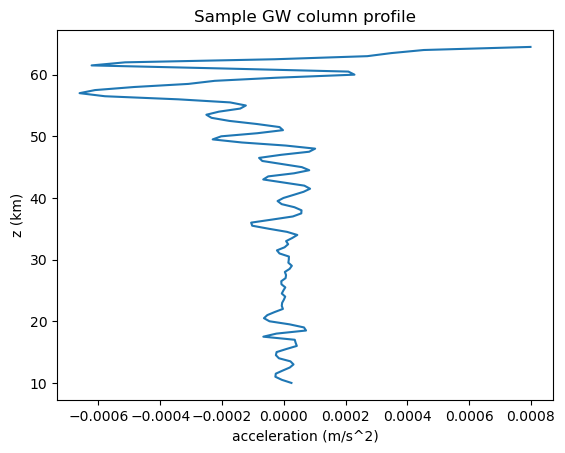

In [8]:
idx = np.random.randint(0,ugw.shape[0])
plt.plot(ugw[idx,:],np.arange(10,65,0.5))
plt.xlabel("acceleration (m/s^2)")
plt.ylabel("z (km)")
plt.title("Sample GW column profile");

/state/partition1/job-44076919/ipykernel_1894075/2879435668.py:3: RuntimeWarning: divide by zero encountered in log10
  counts100 = np.log10(counts100/ugw.shape[0])
/state/partition1/job-44076919/ipykernel_1894075/2879435668.py:6: RuntimeWarning: divide by zero encountered in log10
  counts50 = np.log10(counts50/ugw.shape[0])
/state/partition1/job-44076919/ipykernel_1894075/2879435668.py:9: RuntimeWarning: divide by zero encountered in log10
  counts10 = np.log10(counts10/ugw.shape[0])


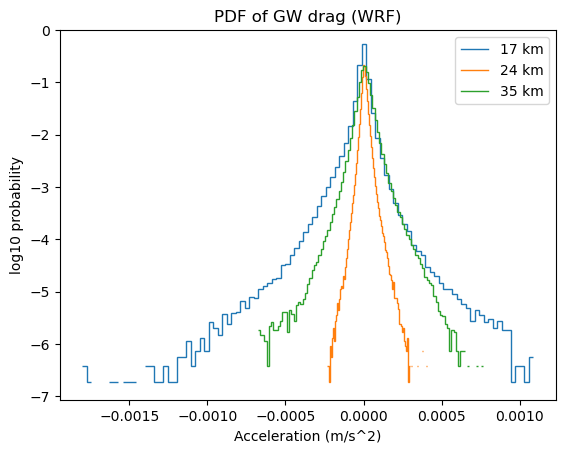

In [10]:
nbins = 100
counts100,bins100 = np.histogram(ugw[:,13],nbins)
counts100 = np.log10(counts100/ugw.shape[0])
plt.stairs(counts100,bins100,baseline=None)
counts50,bins50 = np.histogram(ugw[:,27],nbins)
counts50 = np.log10(counts50/ugw.shape[0])
plt.stairs(counts50,bins50,baseline=None)
counts10,bins10 = np.histogram(ugw[:,49],nbins)
counts10 = np.log10(counts10/ugw.shape[0])
plt.stairs(counts10,bins10,baseline=None)
plt.xlabel("Acceleration (m/s^2)")
plt.ylabel("log10 probability")
plt.legend(["17 km", "24 km", "35 km"])
plt.title("PDF of GW drag (WRF)");

In [7]:
st = 100000      # stride
nchunks = nvec//st
ugw_col_corr = np.zeros((nlev, nlev))
for j in range(nchunks):
    ugw_slice = ugw[j*st:(j+1)*st,:]
    tmp = np.mean(np.expand_dims(ugw_slice,axis=2)*np.expand_dims(ugw_slice,axis=1),axis=0)
    ugw_col_corr += tmp/nchunks
    
corr_diag = np.expand_dims(np.array([np.sqrt(ugw_col_corr[i,i]) for i in range(nlev)]),axis=1)
ugw_col_corr /= corr_diag
ugw_col_corr /= corr_diag.T

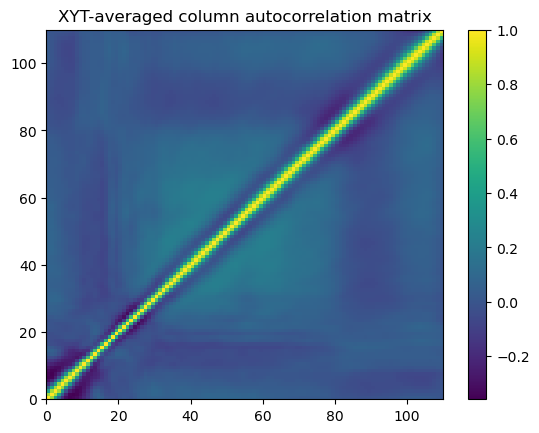

In [9]:
plt.pcolormesh(ugw_col_corr)
plt.title("XYT-averaged column autocorrelation matrix (WRF)");
plt.colorbar();

In [33]:
z = np.arange(10,65,0.5)

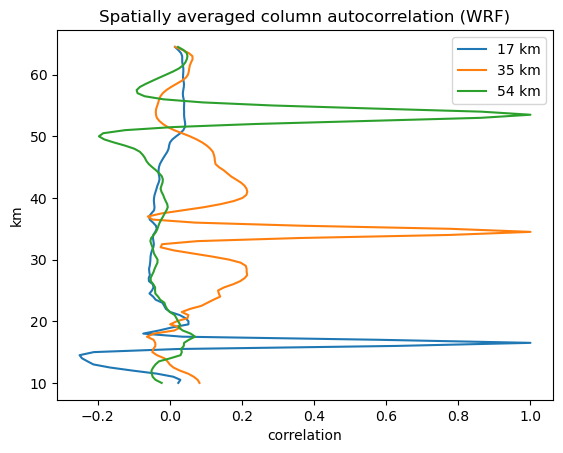

In [26]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(ugw_col_corr[13,:],z)
ax.plot(ugw_col_corr[49,:],z)
ax.plot(ugw_col_corr[87,:],z)
ax.legend(["17 km", "35 km", "54 km"])
plt.ylabel("km")
plt.xlabel("correlation")
#ax.set_ylim(10,65)
plt.title("Spatially averaged column autocorrelation (WRF)");

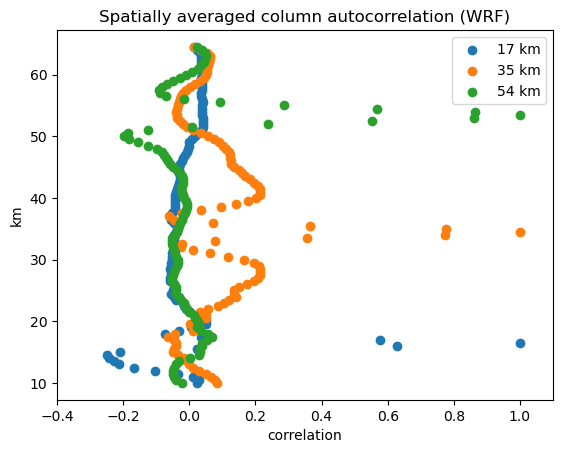

In [24]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(ugw_col_corr[13,:],z)
ax.scatter(ugw_col_corr[49,:],z)
ax.scatter(ugw_col_corr[87,:],z)
ax.legend(["17 km", "35 km", "54 km"])
plt.ylabel("km")
plt.xlabel("correlation")
ax.set_xlim(-0.4,1.1)
plt.title("Spatially averaged column autocorrelation (WRF)");

In [32]:
training_data["UW"].szs

[(95, 111, 38, 47),
 (96, 111, 38, 47),
 (96, 111, 38, 47),
 (96, 111, 38, 47),
 (1, 111, 38, 47)]

In [9]:
# Reshape the dataloader structure into TYX array
# Select zidx = 27 (46 hPa ~ 50 hPa ~ 24km = zidx (24-10)*2-1=27)
# Then average over T to get a 2D array
ndays = len(training_data["UW"].szs)
ugw_box = []
ibegin = 0
for d in range(ndays):
    sz = training_data["UW"].szs[d]
    nvec = sz[0]*sz[2]*sz[3]
    iend = ibegin + nvec
    ugw_box.append(np.swapaxes(np.reshape(ugw[ibegin:iend, :], (sz[0],sz[3],sz[2],sz[1]-1)),1,3))
    ibegin = iend

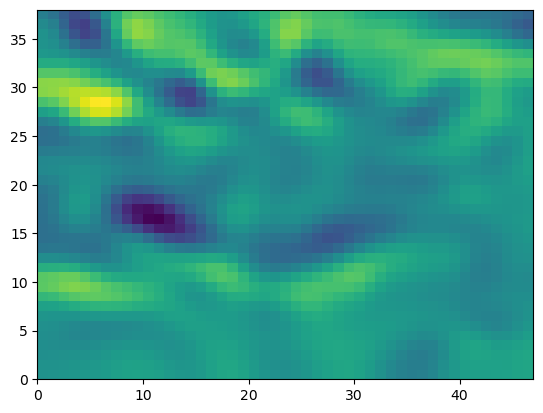

In [11]:
ugw_4d = np.zeros((sum(training_data["UW"].szs[d][0] for d in range(ndays)),sz[1],sz[2],sz[3]))
ibegin = 0
for d in range(ndays):
    sz = ugw_box[d].shape
    iend = ibegin+sz[0]
    ugw_4d[ibegin:iend,:,:,:] = ugw_box[d]
    ibegin=iend
plt.pcolormesh(ugw_4d[1,27,:,:])

In [42]:
# spatial correlation
# 46 hPa ~ 50 hPa ~ 24km = zidx (24-10)*2-1=27
# we want a padded version of ugw to make things easier
TINY = 1e-20
nx = 5
sz = ugw_4d.shape
ugw_hslice = np.zeros((sz[0],1,sz[2]+2*nx,sz[3]+2*nx))
ugw_hslice[:,0,nx:-nx,nx:-nx] = ugw_4d[:,27,:,:]
cnorm = np.sum(ugw_hslice**2,axis=0)
spat_corr = np.zeros((2*nx+1,2*nx+1))
for i in range(-nx,nx):
    for j in range(-nx,nx):
        tmp = np.sum(ugw_hslice[:,0,nx+i:-nx+i,nx+j:-nx+j]*ugw_hslice[:,0,nx:-nx,nx:-nx], axis=0)
        tmp /= TINY + np.sqrt(cnorm[0,nx+i:-nx+i,nx+j:-nx+j]*cnorm[0,nx:-nx,nx:-nx])
        spat_corr[i+nx,j+nx] = np.mean(tmp, axis=(0,1))

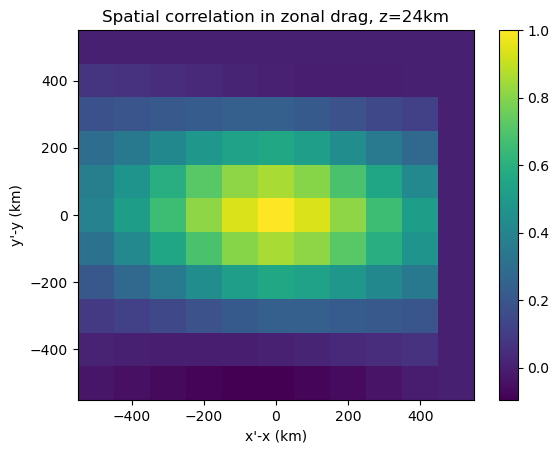

In [40]:
xx = np.arange(-nx,nx+1)*100
plt.pcolormesh(xx,xx,spat_corr)
plt.xlabel("x'-x (km)")
plt.ylabel("y'-y (km)")
plt.title("Spatial correlation in zonal drag, z=24km");
plt.colorbar();

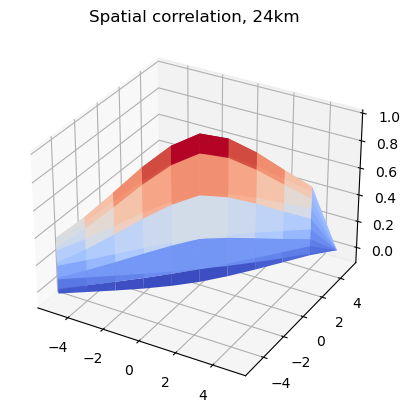

In [33]:
xx = np.arange(-nx,nx+1)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(xx,xx,spat_corr,cmap=cm.coolwarm)
plt.title("Spatial correlation, 24km");
#plt.colorbar();

In [24]:
plt.pcolormesh(spat_corr_pt)
plt.title("Spatial correlation vs. (156,-8.6), 24km");
plt.colorbar();

NameError: name 'spat_corr_pt' is not defined

In [13]:
dat2 = nc.Dataset(input_dir+case_i+dayfile,"r")

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/projects/gerberlab/WRF/INPUT/input_1deg_caseinput_1deg_case1/2016-08-05.nc'

In [44]:
dat2.variables["lon"][0,0,xidx]

masked_array(data=155.86528375,
             mask=False,
       fill_value=1e+20)

In [43]:
dat2.variables["lat"][0,yidx,0]

masked_array(data=-8.57505198,
             mask=False,
       fill_value=1e+20)

In [26]:
ugw.shape

(685824, 110)

In [46]:
ugw_4d.shape

(384, 110, 38, 47)

In [81]:
# temporal autocorrelation
sz = ugw_4d.shape
foo = ugw_4d[:,:,:,:]
foof = ugw_4d[:,:,:,:]
tcorr = np.mean(sg.fftconvolve(foo,np.flip(foof,axis=0),"full",axes=0),axis=(2,3))
tcorr /= tcorr[sz[0]-1,:]

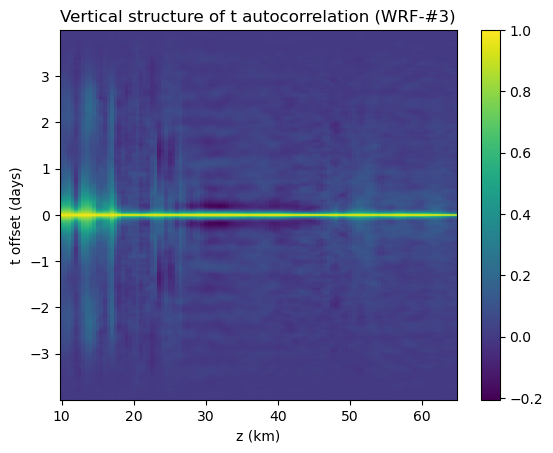

In [82]:
dt = 1/96    # 15min/1day
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.pcolormesh(z,t_ax,tcorr)
plt.xlabel("z (km)")
plt.ylabel("t offset (days)")
plt.title("Vertical structure of t autocorrelation (WRF-#3)")
plt.colorbar();

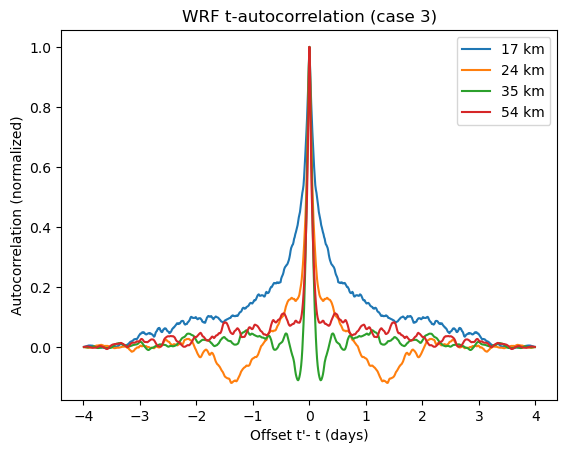

In [83]:
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.plot(t_ax,tcorr[:,13])
plt.plot(t_ax,tcorr[:,27])
plt.plot(t_ax,tcorr[:,49])
plt.plot(t_ax,tcorr[:,87])
plt.xlabel("Offset t'- t (days)")
plt.ylabel("Autocorrelation (normalized)")
plt.legend(["17 km", "24 km", "35 km", "54 km"])
plt.title("WRF t-autocorrelation (case 3)");

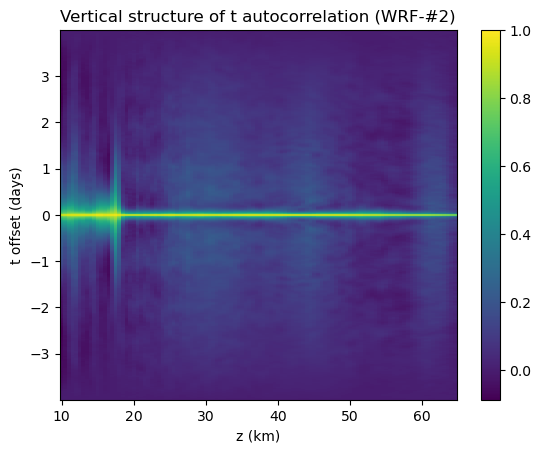

In [72]:
dt = 1/96    # 15min/1day
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.pcolormesh(z,t_ax,tcorr)
plt.xlabel("z (km)")
plt.ylabel("t offset (days)")
plt.title("Vertical structure of t autocorrelation (WRF-#2)")
plt.colorbar();

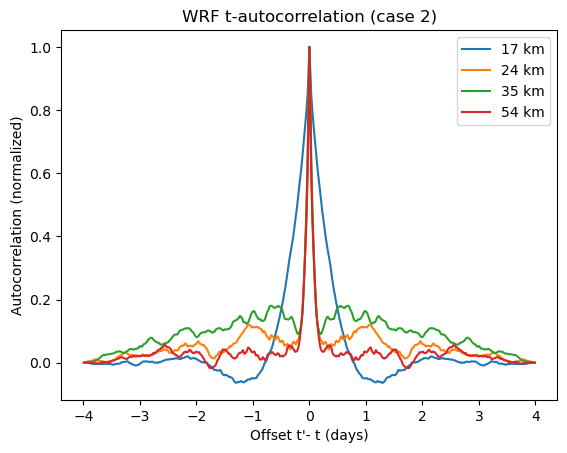

In [71]:
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.plot(t_ax,tcorr[:,13])
plt.plot(t_ax,tcorr[:,27])
plt.plot(t_ax,tcorr[:,49])
plt.plot(t_ax,tcorr[:,87])
plt.xlabel("Offset t'- t (days)")
plt.ylabel("Autocorrelation (normalized)")
plt.legend(["17 km", "24 km", "35 km", "54 km"])
plt.title("WRF t-autocorrelation (case 2)");

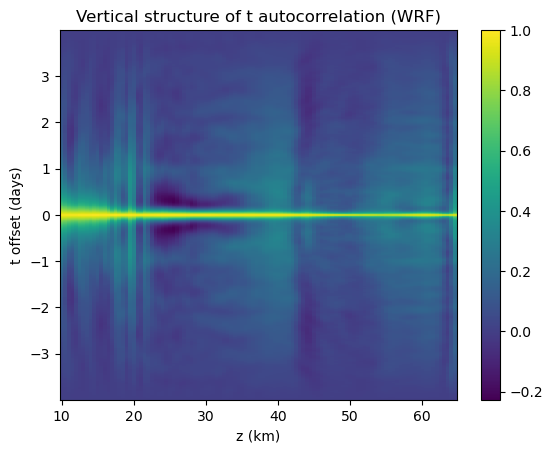

In [49]:
dt = 1/96    # 15min/1day
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.pcolormesh(z,t_ax,tcorr)
plt.xlabel("z (km)")
plt.ylabel("t offset (days)")
plt.title("Vertical structure of t autocorrelation (WRF)")
plt.colorbar();

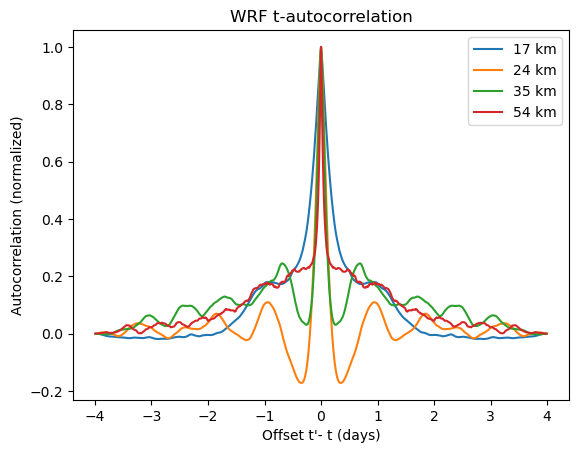

In [48]:
t_ax = np.arange(-(sz[0]-1)*dt,sz[0]*dt,dt)
plt.plot(t_ax,tcorr[:,13])
plt.plot(t_ax,tcorr[:,27])
plt.plot(t_ax,tcorr[:,49])
plt.plot(t_ax,tcorr[:,87])
plt.xlabel("Offset t'- t (days)")
plt.ylabel("Autocorrelation (normalized)")
plt.legend(["17 km", "24 km", "35 km", "54 km"])
plt.title("WRF t-autocorrelation");

In [44]:
t_ax.shape

(384,)

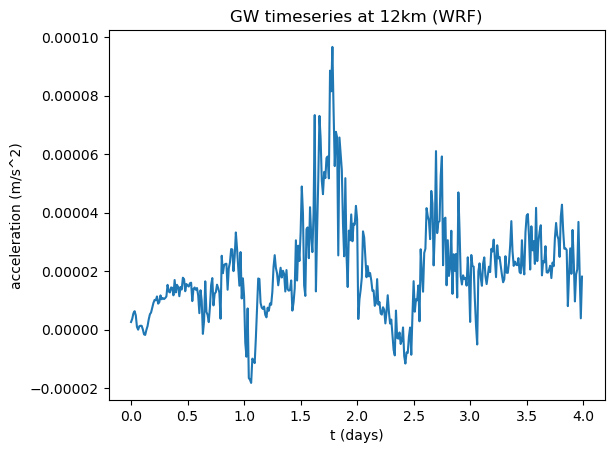

In [60]:
sz = ugw_4d.shape
zr = 1#np.random.randint(0,sz[1])
yr = np.random.randint(0,sz[2])
xr = np.random.randint(0,sz[3])
dt = 1/96          # 15 min/1 day
t_ax = np.arange(0,sz[0]*dt,dt)
plt.plot(t_ax, ugw_4d[:,zr,yr,xr])
plt.xlabel("t (days)")
plt.ylabel("acceleration (m/s^2)")
plt.title("GW timeseries at 12km (WRF)");

In [55]:
# Standard deviations
ugw_std = np.std(ugw_4d,axis=0)

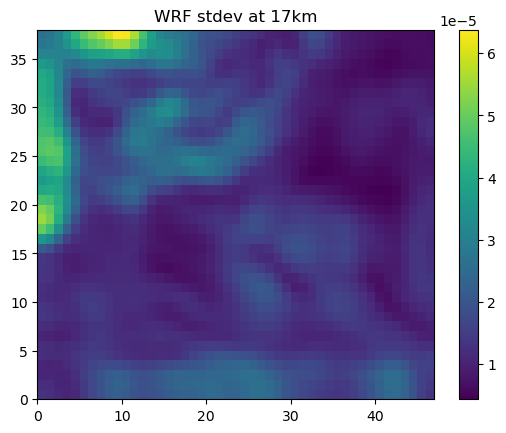

In [57]:
plt.pcolormesh(ugw_std[13,:,:])
plt.title("WRF stdev at 17km")
plt.colorbar();

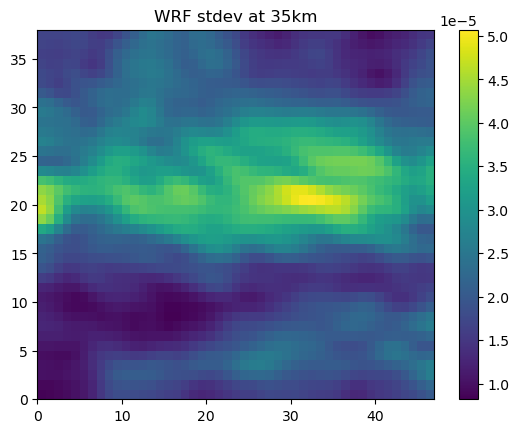

In [58]:
plt.pcolormesh(ugw_std[49,:,:])
plt.title("WRF stdev at 35km")
plt.colorbar();

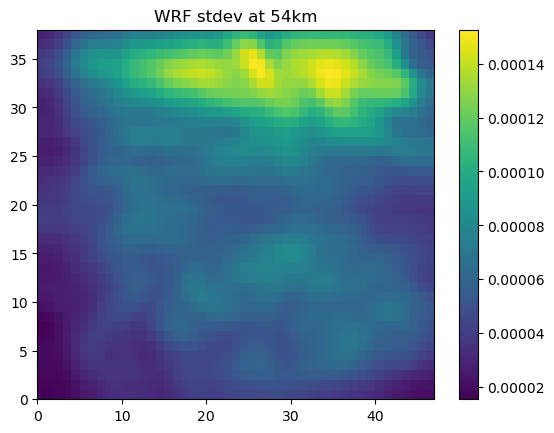

In [59]:
plt.pcolormesh(ugw_std[87,:,:])
plt.title("WRF stdev at 54km")
plt.colorbar();